# HyperSense v1.2 — Regional Adaptation

## Stage 2: Ghana + Nigeria Model Development

### Research Question

Does incorporating Nigerian data into training improve a parsimonious six-feature hypertension model, compared with the Ghana-only HyperSense v1.1 model tested as-is in Stage 1?This stage isolates the effect of adding more local data while keeping the feature set fixed. Stage 3 will evaluate whether adding further features provides additional benefit.

### Background

In Stage 1, the Ghana-derived HyperSense v1.1 model was externally evaluated in the Nigerian REMAH cohort without retraining or recalibration. Discrimination decreased from an AUC of 0.792 in Ghana to 0.747 in the full REMAH cohort, while specificity fell from 0.576 to 0.407 and calibration indicated systematic overprediction. One likely contributor was the `scale_pos_weight` strategy tuned for Ghana's relatively low hypertension prevalence, which did not transfer well to the REMAH population.

Stage 2 therefore incorporates Nigerian data directly into model development. The class-imbalance strategy and decision threshold will be re-derived using the pooled Ghana + REMAH training data rather than inherited from v1.1.

### Outcome

The outcome remains the same measurement-only hypertension definition used in v1.1 and Stage 1. Hypertension is defined as:

- mean SBP ≥140 mmHg, **and/or**
- mean DBP ≥90 mmHg.

All five available blood-pressure readings are required for the outcome calculation (`skipna=False`). Antihypertensive treatment (`HTN_DR`) is not included in the outcome definition.

This preserves the same target construct across Ghana and REMAH and allows the datasets to be pooled validly.

### Predictor Features

The six predictors remain locked to the HyperSense v1.1 feature set:

1. `age`
2. `gender`
3. `residence`
4. `educational_level`
5. `tobacco_use`
6. `bmi`

The harmonization mappings established in Stage 1 will be reused unchanged for REMAH. No additional predictors are introduced at this stage.

### Evaluation Strategy

The pooled Ghana + REMAH dataset will be split into training and test sets using the same stratified 80/20 approach used in v1.1. The resulting test set will be evaluated overall and separately by data source:

- **Pooled test set:** overall performance after regional adaptation.
- **REMAH-origin test subset:** the primary comparison with Stage 1 transportability performance.
- **Ghana-origin test subset:** a sanity check that adaptation does not substantially degrade performance in the original population.

The final model will use the same XGBoost model family and a comparable `RandomizedSearchCV` tuning strategy with internal 10-fold cross-validation. `scale_pos_weight` will be excluded from the hyperparameter search space entirely. Instead, the decision threshold will be re-derived from the pooled training data.

The primary question is whether incorporating Nigerian data improves performance, particularly whether the specificity collapse observed during Stage 1 transportability is reduced in the REMAH-origin test subset.

### 1. Package Versions

In [211]:
# Record package versions for reproducibility

import pandas as pd
import numpy as np
import sklearn
import xgboost

print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost:  {xgboost.__version__}")

pandas:   2.3.3
numpy:    2.4.0
scikit-learn: 1.8.0
xgboost:  3.3.0


### 2. Imports

In [212]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    precision_score,
    recall_score,
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone

# Calibration model for estimating calibration intercept and slope
from sklearn.linear_model import LogisticRegression

# XGBoost
from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 99

np.random.seed(RANDOM_STATE)

### Load the datasets

In [213]:
# Load the Ghana and Nigerian datasets

ghana = pd.read_csv("../outputs/hypersense_v2_data.csv")
nigeria = pd.read_csv("../outputs/transportability/remah_harmonized.csv")

print(f"Ghana dataset:   {len(ghana):,} rows")
print(f"Nigeria dataset: {len(nigeria):,} rows")

Ghana dataset:   7,844 rows
Nigeria dataset: 4,089 rows


In [214]:
# Confirm the required features and outcome are available in both datasets

model_features = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi",
]

outcome = "htn_status"

print("Ghana columns:")
print(ghana[model_features + [outcome]].columns.tolist())

print("\nNigeria columns:")
print(nigeria[model_features + [outcome]].columns.tolist())

Ghana columns:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi', 'htn_status']

Nigeria columns:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi', 'htn_status']


In [215]:
# Check completeness of the locked feature set

print("Ghana missing values:")
print(ghana[model_features + [outcome]].isna().sum())

print("\nNigeria missing values:")
print(nigeria[model_features + [outcome]].isna().sum())

Ghana missing values:
age                  0
gender               0
residence            0
educational_level    0
tobacco_use          0
bmi                  0
htn_status           0
dtype: int64

Nigeria missing values:
age                  0
gender               0
residence            0
educational_level    0
tobacco_use          0
bmi                  0
htn_status           0
dtype: int64


In [216]:
ghana.head()

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi
0,1 1 1,Ghana,856663.0,50.0,1,0,2,0,1.0,1703.0
1,1 3 1,Ghana,856663.0,27.0,1,0,2,0,0.0,2048.0
2,1 6 1,Ghana,856663.0,24.0,1,0,2,0,0.0,2108.0
3,111 1,Ghana,856663.0,40.0,1,0,1,1,0.0,1972.0
4,119 1,Ghana,856663.0,43.0,1,0,2,0,0.0,2300.0


In [217]:
nigeria.head()

,age,gender,residence,educational_level,tobacco_use,bmi,htn_status
0,77.876712,1,0,1.0,1.0,18.832392,0.0
1,53.197260,1,1,1.0,0.0,30.323343,0.0
2,62.287671,1,0,2.0,0.0,19.486961,0.0
3,67.287671,1,0,1.0,0.0,20.202020,0.0
4,34.734247,1,0,3.0,0.0,29.239563,0.0


In [218]:
# Normalize Ghana BMI to match the Nigerian BMI scale

ghana["bmi"] = ghana["bmi"] / 100

print("Ghana BMI range after normalization:")
print(ghana["bmi"].agg(["min", "max"]).round(2))

Ghana BMI range after normalization:
min    13.34
max    54.35
Name: bmi, dtype: float64


In [219]:
# Confirm BMI is on the same scale in both datasets

print("BMI ranges:")
print(
    pd.DataFrame({
        "Ghana": ghana["bmi"].agg(["min", "max"]),
        "Nigeria": nigeria["bmi"].agg(["min", "max"])
    }).round(2)
)

BMI ranges:
     Ghana  Nigeria
min  13.34    11.67
max  54.35    56.30


In [220]:
# Add source labels before pooling

ghana["source"] = "Ghana"
nigeria["source"] = "Nigeria"

# Pool the two datasets while preserving source
pooled = pd.concat(
    [ghana, nigeria],
    axis=0,
    ignore_index=True
)

print(f"Combined dataset: {len(pooled):,} rows")

print("\nRows by source:")
print(pooled["source"].value_counts())

print("\nHypertension prevalence by source:")
print(
    pooled.groupby("source")["htn_status"]
    .mean()
    .mul(100)
    .round(1)
)

Combined dataset: 11,933 rows

Rows by source:
source
Ghana      7844
Nigeria    4089
Name: count, dtype: int64

Hypertension prevalence by source:
source
Ghana      11.5
Nigeria    28.2
Name: htn_status, dtype: float64


In [221]:
# --- Prevalence Calculations ---
# Micro-avg captures the class imbalance for ML thresholding.
# Macro-avg adjusts for the unequal sample sizes between Ghana/Nigeria for the sake of reporting.

# 1. Micro-average (True data distribution baseline)
micro_prevalence = pooled["htn_status"].mean()
print(f"Overall Data Pool Prevalence (Micro-Avg): {micro_prevalence:.2f}")

# 2. Macro-average (Regional baseline)
country_rates = pooled.groupby("source")["htn_status"].mean()
macro_prevalence = country_rates.mean()
print(f"Overall Regional Prevalence (Macro-Avg): {macro_prevalence:.2f}")


Overall Data Pool Prevalence (Micro-Avg): 0.17
Overall Regional Prevalence (Macro-Avg): 0.20


In [222]:
pooled.head()

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi,source
0,1 1 1,Ghana,856663.0,50.0,1,0,2.0,0.0,1.0,17.03,Ghana
1,1 3 1,Ghana,856663.0,27.0,1,0,2.0,0.0,0.0,20.48,Ghana
2,1 6 1,Ghana,856663.0,24.0,1,0,2.0,0.0,0.0,21.08,Ghana
3,111 1,Ghana,856663.0,40.0,1,0,1.0,1.0,0.0,19.72,Ghana
4,119 1,Ghana,856663.0,43.0,1,0,2.0,0.0,0.0,23.00,Ghana


In [223]:
# Retain only the locked features, outcome, and source indicator from 'pooled'

model_columns = model_features + [outcome, "source"]

pooled_model = pooled[model_columns].copy()

print("Modeling dataset columns:")
print(pooled_model.columns.tolist())

print(f"\nModeling dataset shape: {pooled_model.shape}")

print("\nExcluded columns:")
excluded_columns = [column for column in pooled.columns if column not in model_columns]
print(excluded_columns)

Modeling dataset columns:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi', 'htn_status', 'source']

Modeling dataset shape: (11933, 8)

Excluded columns:
['caseid', 'country', 'sample_weight']


### 3. Pooled Train/Test Split

The pooled dataset is split into training and test sets using an 80/20 stratified split. Stratification is performed jointly on data source and hypertension status to preserve the Ghana/Nigeria composition and outcome distribution across both partitions.

In [224]:
# Create a combined stratification variable
pooled_model["stratify_group"] = (
    pooled_model["source"].astype(str)
    + "_"
    + pooled_model["htn_status"].astype(str)
)

# Stratified 80/20 train/test split
train_data, test_data = train_test_split(
    pooled_model,
    test_size=0.20,
    stratify=pooled_model["stratify_group"],
    random_state=RANDOM_STATE
)

# Remove the temporary stratification variable
train_data = train_data.drop(columns="stratify_group")
test_data = test_data.drop(columns="stratify_group")

print(f"Training set: {len(train_data):,} rows")
print(f"Test set: {len(test_data):,} rows")

Training set: 9,546 rows
Test set: 2,387 rows


### 4. Source and Outcome Composition After Splitting

The source and hypertension-status distributions are checked separately in the training and test sets to confirm that both partitions retain comparable Ghana/Nigeria composition and outcome prevalence.

In [225]:
# Report source composition within each split

for split_name, split_data in [
    ("Training", train_data),
    ("Test", test_data)
]:
    print(f"{split_name} set — source composition:")
    print(
        split_data["source"]
        .value_counts()
        .rename_axis("source")
        .to_frame("n")
    )

    print("\nSource proportion:")
    print(
        split_data["source"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .rename_axis("source")
        .to_frame("percent")
    )

    print()

Training set — source composition:
            n
source       
Ghana    6275
Nigeria  3271

Source proportion:
         percent
source          
Ghana       65.7
Nigeria     34.3

Test set — source composition:
            n
source       
Ghana    1569
Nigeria   818

Source proportion:
         percent
source          
Ghana       65.7
Nigeria     34.3



In [226]:
# Check hypertension prevalence within each source and split

for split_name, split_data in [
    ("Training", train_data),
    ("Test", test_data)
]:
    print(f"{split_name} set — hypertension prevalence by source:")
    print(
        split_data.groupby("source")["htn_status"]
        .mean()
        .mul(100)
        .round(1)
        .rename("prevalence_percent")
    )

    print()

Training set — hypertension prevalence by source:
source
Ghana      11.5
Nigeria    28.2
Name: prevalence_percent, dtype: float64

Test set — hypertension prevalence by source:
source
Ghana      11.5
Nigeria    28.1
Name: prevalence_percent, dtype: float64



In [227]:
# Check pooled data again
print(pooled_model.shape)
pooled_model.head()

(11933, 9)


,age,gender,residence,educational_level,tobacco_use,bmi,htn_status,source,stratify_group
0,50.0,1,0,2.0,0.0,17.03,1.0,Ghana,Ghana_1.0
1,27.0,1,0,2.0,0.0,20.48,0.0,Ghana,Ghana_0.0
2,24.0,1,0,2.0,0.0,21.08,0.0,Ghana,Ghana_0.0
3,40.0,1,0,1.0,1.0,19.72,0.0,Ghana,Ghana_0.0
4,43.0,1,0,2.0,0.0,23.00,0.0,Ghana,Ghana_0.0


### 5. Feature & Target Preparation

The modelling dataset is separated into predictor variables and the hypertension outcome. Country/Source is retained for subgroup evaluation but is excluded from the model predictors, while the temporary stratification variable is discarded. 

In [228]:
# Define modelling features and target
FEATURES = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi"
]

TARGET = "htn_status"

# Create training and test matrices
X_train = train_data[FEATURES].copy()
y_train = train_data[TARGET].copy()

X_test = test_data[FEATURES].copy()
y_test = test_data[TARGET].copy()

# Preserve source labels for subgroup evaluation
source_train = train_data["source"].copy()
source_test = test_data["source"].copy()

print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

print("\nFeatures:")
print(FEATURES)

print("\nTraining outcome distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

print("\nTest outcome distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Training features: (9546, 6)
Test features: (2387, 6)

Features:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi']

Training outcome distribution:
htn_status
0.0    82.8
1.0    17.2
Name: proportion, dtype: float64

Test outcome distribution:
htn_status
0.0    82.8
1.0    17.2
Name: proportion, dtype: float64


### 6. Pooled Regional Baseline Model

A baseline classifier is trained on the combined Ghanaian and Nigerian training data. This provides a reference for evaluating a model trained on data from both countries. The held-out test set is used only for final evaluation and is not used for model development or selection.

In [229]:
# Initialize pooled baseline model
baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the pooled baseline model
baseline_model.fit(
    X_train,
    y_train
)

print("Pooled baseline model successfully trained.")

Pooled baseline model successfully trained.


In [230]:
# Generate test-set predictions
y_test_proba = baseline_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.50).astype(int)

print(f"Test predictions generated: {len(y_test_pred):,}")

Test predictions generated: 2,387


### 7. Pooled Baseline Evaluation

The pooled baseline is evaluated on the held-out test set using overall discrimination and classification performance, followed by separate evaluation within Ghana and Nigeria to assess regional heterogeneity.

In [231]:
# Overall discrimination and classification performance

# Overall discrimination
auc = roc_auc_score(y_test, y_test_proba)

# Classification performance at the current 0.50 threshold
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

# Brier score
brier = brier_score_loss(y_test, y_test_proba)

print("Pooled baseline — overall performance")
print(f"AUC:          {auc:.3f}")
print(f"Sensitivity:  {sensitivity:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"PPV:          {ppv:.3f}")
print(f"NPV:          {npv:.3f}")
print(f"Brier score:  {brier:.3f}")
print("Threshold:    0.50")

Pooled baseline — overall performance
AUC:          0.772
Sensitivity:  0.260
Specificity:  0.946
PPV:          0.502
NPV:          0.860
Brier score:  0.126
Threshold:    0.50


In [232]:
# Calibration intercept & scope

# Clip probabilities to avoid infinite log-odds when p = 0 or p = 1
proba_clipped = np.clip(y_test_proba, 1e-6, 1 - 1e-6)

# Convert predicted probabilities to log-odds
logit_proba = np.log(
    proba_clipped / (1 - proba_clipped)
).reshape(-1, 1)

# Calibration intercept & slope
calibration_model = LogisticRegression(
    C=np.inf,
    solver="lbfgs"
)

calibration_model.fit(logit_proba, y_test)

calibration_intercept = calibration_model.intercept_[0]
calibration_slope = calibration_model.coef_[0, 0]

print("Calibration")
print(f"Intercept: {calibration_intercept:.3f}")
print(f"Slope:     {calibration_slope:.3f}")

Calibration
Intercept: -0.423
Slope:     0.623


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


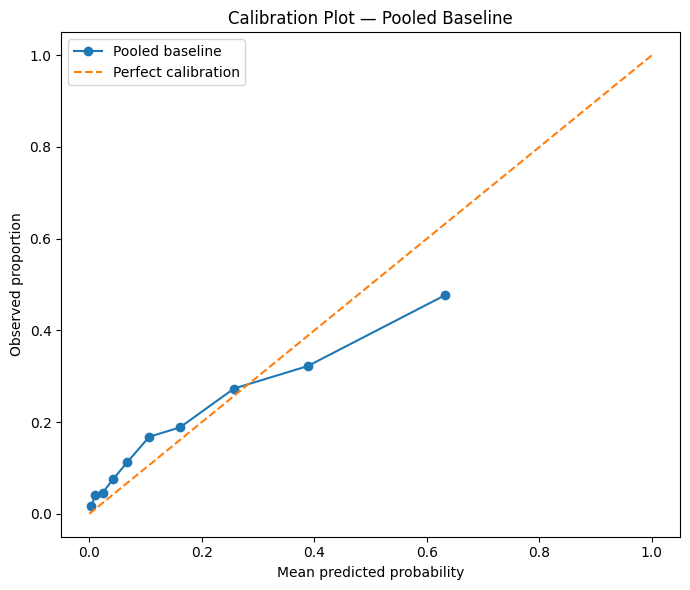

In [237]:
# Calibration plot

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Pooled baseline"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion")
plt.title("Calibration Plot — Pooled Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [240]:
# Evaluate regional performance
regional_results = []

for source in ["Ghana", "Nigeria"]:
    mask = source_test == source

    y_true_source = y_test[mask]
    y_proba_source = y_test_proba[mask]
    y_pred_source = y_test_pred[mask]

    tn, fp, fn, tp = confusion_matrix(
        y_true_source,
        y_pred_source
    ).ravel()

    regional_results.append({
        "source": source,
        "n": len(y_true_source),
        "auc": roc_auc_score(y_true_source, y_proba_source),
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "ppv": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "npv": tn / (tn + fn) if (tn + fn) > 0 else 0,
        "brier": brier_score_loss(y_true_source, y_proba_source)
    })

regional_results = pd.DataFrame(regional_results)

regional_results

,source,n,auc,sensitivity,specificity,ppv,npv,brier
0,Ghana,1569,0.741842,0.099448,0.980548,0.400000,0.893045,0.098323
1,Nigeria,818,0.742487,0.386957,0.865646,0.529762,0.783077,0.179970
